# CSC 487 Final Project
By: Pranav Krishna, Ahad Jiva, Milad Chabok, Pranav Nallaperumal

*Note*: Ensure you install dependencies with `!pip install -r requirements.txt` or `!pip install -r requirements-cuda.txt` and place your `.env` file containing `GEMINI_API_KEY=your_key` in the project root.

In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil
import kagglehub
from google.genai import types
import json
import os
from dotenv import load_dotenv

/Users/ahadj/Desktop/25-26/Winter Quarter/CSC 487/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Grab data from csv, import to dataframe, split into features and labels

In [2]:
# If dataset not downloaded
path = kagglehub.dataset_download("priyamchoksi/credit-card-transactions-dataset")
print("Path to dataset files:", path)

# move/copy the csv to current directory
for file in os.listdir(path):
    if file.endswith('.csv'):
        source_file = os.path.join(path, file)
        target_file = 'credit_card_transactions.csv'
        if not os.path.exists(target_file):
            shutil.copy(source_file, target_file)
            print(f"Copied {file} to {target_file}")
        else:
            print(f"{target_file} already exists.")
        break


Path to dataset files: /Users/ahadj/.cache/kagglehub/datasets/priyamchoksi/credit-card-transactions-dataset/versions/1
credit_card_transactions.csv already exists.


In [3]:
df = pd.read_csv("credit_card_transactions.csv")

print(df.head())
print(df.columns)

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      long city_pop  \
0    Banks      F                561 Perry Cove  ...  -81.1781     3495   
1     Gill      F  43039 Riley Greens Suite 393  ... -11

## LLM Step format job categories

In [4]:
import os
import json
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()

unique_jobs = [j for j in df['job'].unique() if isinstance(j, str)]
job_map = None

MAX_LLM_CATEGORIES = 10
cache_file = f'job_encodings_{MAX_LLM_CATEGORIES}.txt'

print(unique_jobs)

if os.path.exists(cache_file):
    print(f"Loading cached job encodings from {cache_file}...")
    with open(cache_file, 'r', encoding='utf-8') as f:
        job_map = json.load(f)
        if(not job_map.get('mappings')):
            job_map = None

if(job_map == None):
    print(f"Calling Gemini API to encode job categories into max {MAX_LLM_CATEGORIES} categories...")
    client = genai.Client() # auto-loads GEMINI_API_KEY from env
    
    prompt = f"""Categorize the following job titles into much broader categories, not exceeding {MAX_LLM_CATEGORIES} categories.
                 Assign each a numeric category ID from 0 to {MAX_LLM_CATEGORIES - 1}. 
                 Return ONLY a valid JSON dictionary which has two parts.
                 The first part `categories` is the categories you generated along with their key.
                 The second part `mappings` are the exact job titles from my data which are mapped to their numeric ID of the more
                 broad categories you generated. 
                 Jobs to categorize:\n{unique_jobs}"""
    
    response = client.models.generate_content(
        model='gemini-3-flash-preview',
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            temperature=0.1
        )
    )
    
    try:
        job_map = json.loads(response.text.strip())
        with open(cache_file, 'w', encoding='utf-8') as f:
            json.dump(job_map, f, ensure_ascii=False, indent=4)
        print(f"Saved job encodings to {cache_file}")
    except Exception as e:
        print(f"Failed to parse JSON: {e}")
        print(response.text)
        job_map = {'mappings': {job: 0 for job in unique_jobs}, 'categories': {}}

# Map to the dataframe
if(job_map.get('mappings')):
    df['job'] = df['job'].map(job_map['mappings']).fillna(0).astype('int64')

['Psychologist, counselling', 'Special educational needs teacher', 'Nature conservation officer', 'Patent attorney', 'Dance movement psychotherapist', 'Transport planner', 'Arboriculturist', 'Designer, multimedia', 'Public affairs consultant', 'Pathologist', 'IT trainer', 'Systems developer', 'Engineer, land', 'Systems analyst', 'Naval architect', 'Radiographer, diagnostic', 'Programme researcher, broadcasting/film/video', 'Energy engineer', 'Event organiser', 'Operational researcher', 'Market researcher', 'Probation officer', 'Leisure centre manager', 'Corporate investment banker', 'Therapist, occupational', 'Call centre manager', 'Police officer', 'Education officer, museum', 'Physiotherapist', 'Network engineer', 'Forensic psychologist', 'Geochemist', 'Armed forces training and education officer', 'Designer, furniture', 'Optician, dispensing', 'Psychologist, forensic', 'Librarian, public', 'Fine artist', 'Scientist, research (maths)', 'Research officer, trade union', 'Tourism office

In [5]:
X = df.loc[:, ~df.columns.isin(["is_fraud", "Unnamed: 0"])].select_dtypes(include=np.number)
y = df["is_fraud"]

X, y

print(X.columns)
print(df.loc[:, ~df.columns.isin(["is_fraud", "Unnamed: 0"])].columns)


Index(['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'job', 'unix_time',
       'merch_lat', 'merch_long', 'merch_zipcode'],
      dtype='object')
Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'merch_zipcode'],
      dtype='object')


## Remove bad values and check for empty values

In [6]:
bad = X.isna().any(axis=1)
X = X[~bad]
y = y[~bad]

na_x = X.isna().sum(axis=0)
na_y = y.isna().sum(axis=0)

print(na_x, na_y)

cc_num           0
amt              0
zip              0
lat              0
long             0
city_pop         0
job              0
unix_time        0
merch_lat        0
merch_long       0
merch_zipcode    0
dtype: int64 0


## Turning them into np arrays

In [7]:

X = X.values.astype('float32')
y = y.values.astype('int64')

## Convert to Torch tensors

In [8]:
# lster on

## Convert to tensor dataset, train test split

In [9]:
from torch.utils.data import TensorDataset, DataLoader
from torchsampler import ImbalancedDatasetSampler

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SVMSMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

smote = SVMSMOTE(sampling_strategy='minority', random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

#tryna avoid data leakage
avg = X_train.mean(axis=0, keepdims=True)
stdev = X_train.std(axis=0, keepdims=True)

X_train = (X_train - avg) / stdev
X_test = (X_test - avg) / stdev

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).long()

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, sampler=ImbalancedDatasetSampler(train_data), batch_size=2048, shuffle=False)
# train_loader = DataLoader(train_data, batch_size=2048, shuffle=True)
test_loader = DataLoader(test_data, batch_size=2048, shuffle=False)

/Users/ahadj/Desktop/25-26/Winter Quarter/CSC 487/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


## Model Architecture

In [10]:
device = 'cpu'
if(torch.backends.mps.is_available()):
    print("Using mps")
    device = 'mps'
elif(torch.cuda.is_available()):
    print("Using cuda")
    device = 'cuda'
else:
    print("Using CPU")

linear_model = torch.nn.Sequential(
    torch.nn.Linear(11, 512),
    torch.nn.GELU(),
    torch.nn.Linear(512, 2048),
    torch.nn.GELU(),
    torch.nn.Linear(2048, 1024),
    torch.nn.GELU(),
    torch.nn.Linear(1024, 256),
    torch.nn.GELU(),
    torch.nn.Linear(256, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 2)
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
lr = 3e-4
opt = torch.optim.AdamW(linear_model.parameters(), lr=lr)

Using mps


In [11]:
epoch_losses = []
for epoch in range(10):
    pbar = tqdm(train_loader, desc=f'Epoch: {epoch}')
    batch_losses = []
    for batch in pbar:
        X_batch, y_batch = batch
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = linear_model(X_batch)
        loss = loss_fn(pred, y_batch)
        opt.zero_grad()
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())
        pbar.set_postfix({'loss': loss.item()})
    epoch_losses.append(np.mean(batch_losses))

Epoch: 9: 100%|██████████| 855/855 [00:18<00:00, 45.89it/s, loss=0.0447]


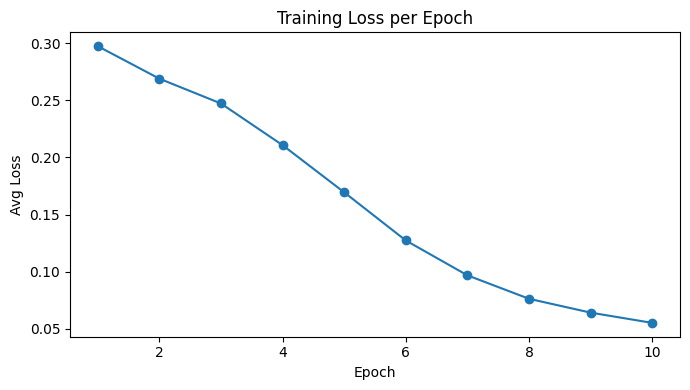

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Avg Loss')
plt.title('Training Loss per Epoch')
plt.tight_layout()
plt.show()

Predicting...: 100%|██████████| 108/108 [00:01<00:00, 95.71it/s] 


Accuracy: 0.9691107063200404


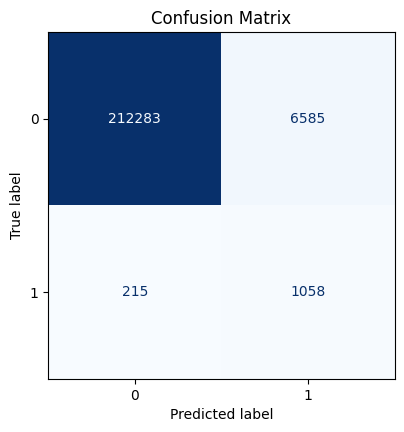

In [13]:
linear_model.eval()

correct = 0
total = 0

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Predicting..."):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = linear_model(X_batch)
        predicted_labels = pred.argmax(dim=1)
        probs = torch.softmax(pred, dim=1)[:, 1]

        y_true.append(y_batch.cpu())
        y_pred.append(predicted_labels.cpu())
        y_prob.append(probs.cpu())

        correct += (predicted_labels == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy}")

# Confusion matrix (sklearn)
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()
y_prob = torch.cat(y_prob).numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix")
plt.show()

In [14]:
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0
total_fraud = y_test.sum()

print(
    f"total fraud: {total_fraud}\n"
    f"true positives: {tp}\n"
    f"true negatives: {tn}\n"
    f"false positives: {fp}\n"
    f"false negatives: {fn}\n"
    f"precision: {precision}\n"
    f"recall: {recall}\n"
    f"f1: {f1}\n"
    f"% of fraudulent transactions in test set classified incorrectly: {fn / total_fraud}"
)

total fraud: 1273
true positives: 1058
true negatives: 212283
false positives: 6585
false negatives: 215
precision: 0.13842731911553055
recall: 0.8311076197957581
f1: 0.237326155226559
% of fraudulent transactions in test set classified incorrectly: 0.16889238357543945


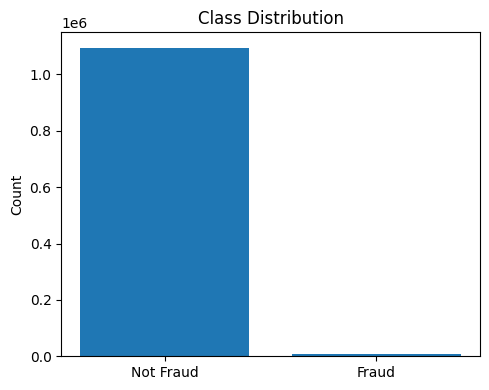

In [15]:
labels = ['Not Fraud', 'Fraud']
counts = [(y == 0).sum(), (y == 1).sum()]

plt.figure(figsize=(5, 4))
plt.bar(labels, counts)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

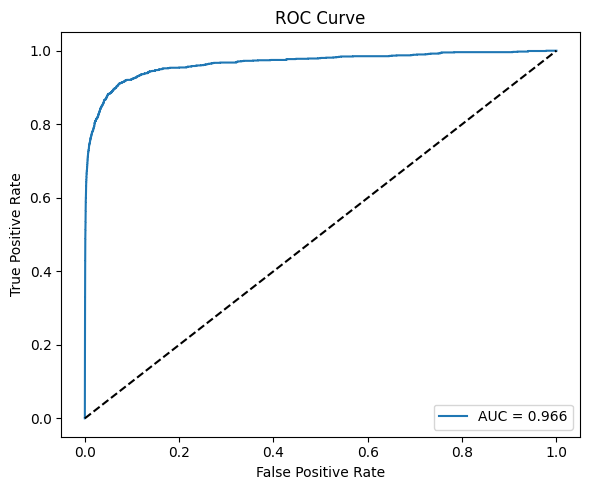

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

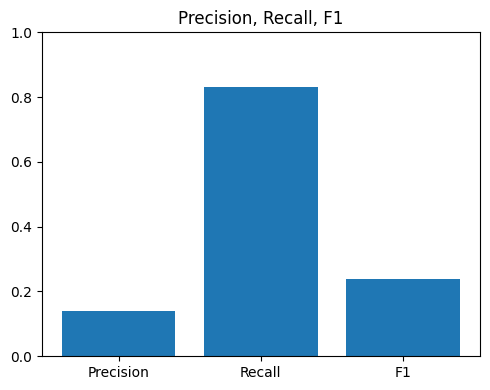

In [17]:
metric_names = ['Precision', 'Recall', 'F1']
metric_values = [precision, recall, f1]

plt.figure(figsize=(5, 4))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.title('Precision, Recall, F1')
plt.tight_layout()
plt.show()